<a href="https://colab.research.google.com/github/SamShinwari/Advanced-AI-Bootcamp-2026/blob/main/Project_3_N_Gram_Analysis_(Unigram%2C_Bigram%2C_Trigram).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project 3: N-Gram Analysis (Unigram, Bigram, Trigram)

### Objective

In this project, you'll learn how to extract frequently occurring single words, two-word phrases, and three-word phrases from your news dataset.

For example:

| N-Gram  | Example                  |
| :------ | :----------------------- |
| Unigram | ukraine                  |
| Bigram  | ukraine war              |
| Trigram | russian military invasion|

N-grams are widely used in:

*   Text Classification
*   Machine Translation
*   Search Engines
*   Next Word Prediction
*   Language Modeling
*   Chatbots

### Step 1: Import Libraries

In [33]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from google.colab import drive

In [34]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [35]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Load Dataset

In [36]:
file_path = '/content/drive/MyDrive/Colab Notebooks/bbc_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [51]:
df = df.dropna(subset=["description"])
df = df.drop_duplicates(subset=["description"])
df = df.reset_index(drop=True)

In [38]:
df = df.drop(columns=['guid', 'link','pubDate'])
df.head()

,title,description
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...


In [39]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    words = text.split()
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Join words back into a string
    return ' '.join(words)

# Apply the preprocessing function to the 'description' column to create 'clean_text'
df['clean_text'] = df['description'].apply(preprocess_text)

print(df[['description', 'clean_text']].head())

                                         description  \
0  The Ukrainian president says the country will ...   
1  Jeremy Bowen was on the frontline in Irpin, as...   
2  One of the world's biggest fertiliser firms sa...   
3  The parents of the Manchester Arena bombing's ...   
4  Consumers are feeling the impact of higher ene...   

                                          clean_text  
0  ukrainian president say country forgive forget...  
1  jeremy bowen frontline irpin resident came rus...  
2  one world biggest fertiliser firm say conflict...  
3  parent manchester arena bombing youngest victi...  
4  consumer feeling impact higher energy cost fue...  


Your dataset should contain the `clean_text` column.

### Step 3: Display Sample Text

In [40]:
print(df["description"].iloc[0])

The Ukrainian president says the country will not forgive or forget those who murder its civilians.


### Step 4: Unigram Analysis

A unigram is a single word.

In [41]:
vectorizer = CountVectorizer(ngram_range=(1,1))

X = vectorizer.fit_transform(df["clean_text"])

word_counts = X.sum(axis=0).A1

words = vectorizer.get_feature_names_out()

unigram_df = pd.DataFrame({
    "Word": words,
    "Frequency": word_counts
})

unigram_df = unigram_df.sort_values(
    by="Frequency",
    ascending=False
)

print(unigram_df.head(20))

             Word  Frequency
21827         say       5110
27448       world       1958
7889      england       1883
27633        year       1817
2222          bbc       1595
9120        first       1553
18563      people       1549
16990         new       1519
5732          cup       1413
25764          uk       1259
5987          day       1235
27278         win       1219
14071      league       1212
17669         one       1166
25667         two       1114
4426         city        915
19036      police        893
9464       former        871
15118  manchester        855
5379        could        853


#### Example Output

| Word    | Frequency |
| :------ | :-------- |
| ukraine | 420       |
| war     | 390       |
| russian | 350       |
| covid   | 280       |

### Step 5: Plot Top 20 Unigrams

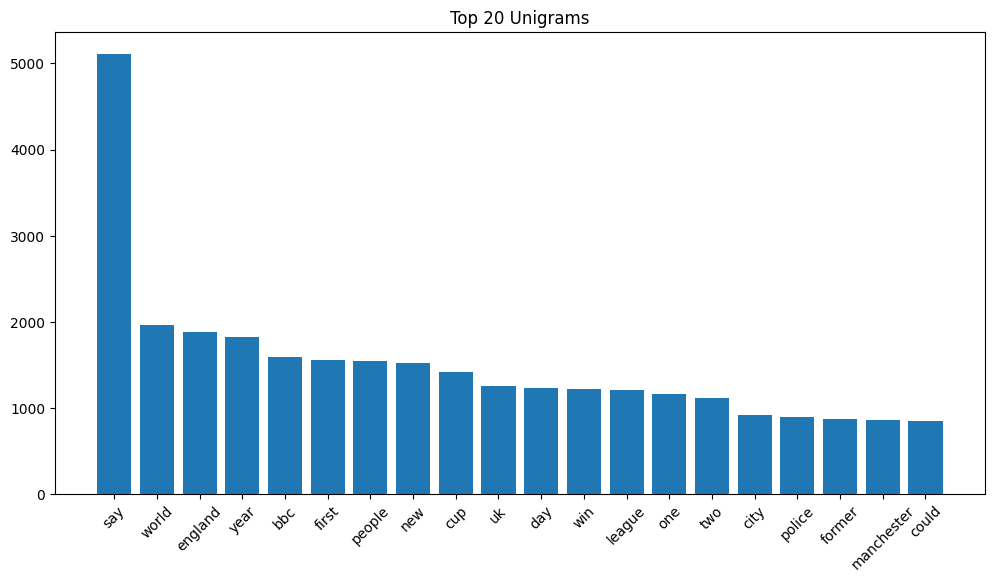

In [42]:
top20 = unigram_df.head(20)

plt.figure(figsize=(12,6))
plt.bar(top20["Word"], top20["Frequency"])
plt.xticks(rotation=45)
plt.title("Top 20 Unigrams")
plt.show()

### Step 6: Bigram Analysis

A bigram is two consecutive words.

#### Example

*   Ukraine War
*   Oil Price
*   Russian Forces
*   Prime Minister

In [43]:
vectorizer = CountVectorizer(ngram_range=(2,2))

X = vectorizer.fit_transform(df["clean_text"])

counts = X.sum(axis=0).A1

phrases = vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({
    "Bigram": phrases,
    "Frequency": counts
})

bigram_df = bigram_df.sort_values(
    by="Frequency",
    ascending=False
)

print(bigram_df.head(20))

                   Bigram  Frequency
222748          world cup        985
149666     premier league        502
118600    manchester city        365
118635  manchester united        336
151020     prime minister        307
16467           bbc sport        287
31073     champion league        281
197688           tell bbc        247
73243          first time        234
147534         police say        212
164469        rishi sunak        211
78511          front page        193
183332      social medium        193
221894       womens world        193
177386          seven day        185
141476         past seven        180
66573              fa cup        178
45740           cup final        164
216475    watch highlight        162
184244       south africa        154


#### Example Output

| Bigram         | Frequency |
| :------------- | :-------- |
| ukraine war    | 155       |
| russian force  | 121       |
| oil price      | 92        |
| prime minister | 74        |

### Step 7: Plot Top Bigrams

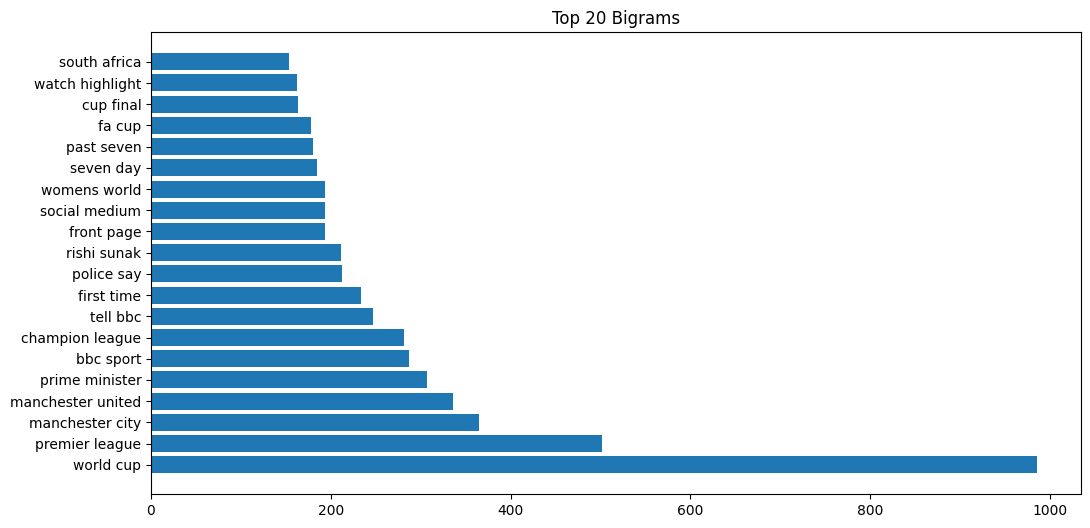

In [44]:
top20 = bigram_df.head(20)

plt.figure(figsize=(12,6))
plt.barh(top20["Bigram"], top20["Frequency"])

plt.title("Top 20 Bigrams")

plt.show()

### Step 8: Trigram Analysis

A trigram contains three consecutive words.

#### Examples

*   war in ukraine
*   prime minister boris
*   cost of living

#### Code

In [45]:
vectorizer = CountVectorizer(ngram_range=(3,3))

X = vectorizer.fit_transform(df["clean_text"])

counts = X.sum(axis=0).A1

phrases = vectorizer.get_feature_names_out()

trigram_df = pd.DataFrame({
    "Trigram": phrases,
    "Frequency": counts
})

trigram_df = trigram_df.sort_values(
    by="Frequency",
    ascending=False
)

print(trigram_df.head(20))

                         Trigram  Frequency
260181          womens world cup        186
164489            past seven day        180
40625   closely paying attention        106
95295           going past seven        106
261259           world cup final         96
256275          whats going past         84
165157    paying attention whats         84
205687  selection striking image         84
14059      attention whats going         84
228835          taken past seven         74
260161       womens super league         72
71212               erik ten hag         66
261356    world cup quarterfinal         57
174469      premier league title         57
139183          match day pundit         57
18546             bbc sport look         55
83232           first time since         52
261624          world number one         49
180434        queen elizabeth ii         48
261383       world cup semifinal         46


### Step 9: Plot Top Trigrams

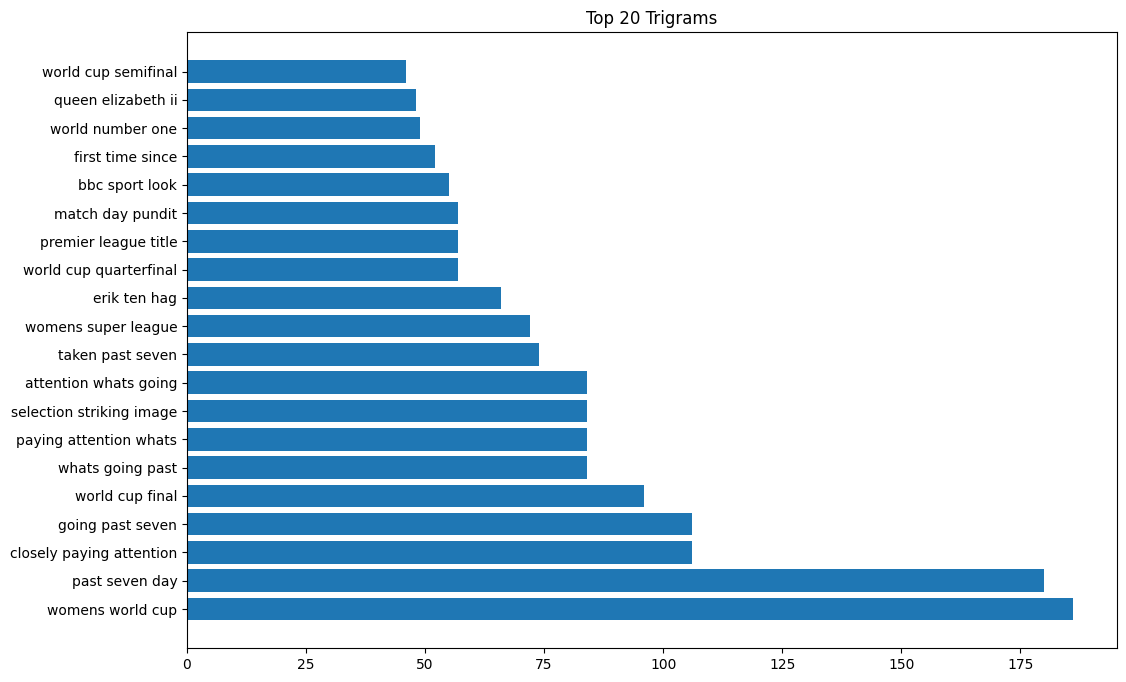

In [46]:
top20 = trigram_df.head(20)

plt.figure(figsize=(12,8))
plt.barh(top20["Trigram"], top20["Frequency"])

plt.title("Top 20 Trigrams")

plt.show()

### Step 10: Compare Unigrams, Bigrams, and Trigrams

In [47]:
print("Top Unigrams")
print(unigram_df.head(10))

print("\nTop Bigrams")
print(bigram_df.head(10))

print("\nTop Trigrams")
print(trigram_df.head(10))

Top Unigrams
          Word  Frequency
21827      say       5110
27448    world       1958
7889   england       1883
27633     year       1817
2222       bbc       1595
9120     first       1553
18563   people       1549
16990      new       1519
5732       cup       1413
25764       uk       1259

Top Bigrams
                   Bigram  Frequency
222748          world cup        985
149666     premier league        502
118600    manchester city        365
118635  manchester united        336
151020     prime minister        307
16467           bbc sport        287
31073     champion league        281
197688           tell bbc        247
73243          first time        234
147534         police say        212

Top Trigrams
                         Trigram  Frequency
260181          womens world cup        186
164489            past seven day        180
40625   closely paying attention        106
95295           going past seven        106
261259           world cup final         96
256

### Step 11: Save Results

In [48]:
unigram_df.to_csv("unigrams.csv", index=False)

bigram_df.to_csv("bigrams.csv", index=False)

trigram_df.to_csv("trigrams.csv", index=False)

print("Files Saved Successfully")

Files Saved Successfully


### Complete Reusable Function

In [49]:
def generate_ngrams(text_column, n):

    vectorizer = CountVectorizer(
        ngram_range=(n, n)
    )

    X = vectorizer.fit_transform(text_column)

    counts = X.sum(axis=0).A1

    terms = vectorizer.get_feature_names_out()

    df = pd.DataFrame({
        "N-Gram": terms,
        "Frequency": counts
    })

    return df.sort_values(
        by="Frequency",
        ascending=False
    )

Use it like this:

In [50]:
unigrams = generate_ngrams(df["clean_text"], 1)

bigrams = generate_ngrams(df["clean_text"], 2)

trigrams = generate_ngrams(df["clean_text"], 3)

print(unigrams.head())

print(bigrams.head())

print(trigrams.head())

        N-Gram  Frequency
21827      say       5110
27448    world       1958
7889   england       1883
27633     year       1817
2222       bbc       1595
                   N-Gram  Frequency
222748          world cup        985
149666     premier league        502
118600    manchester city        365
118635  manchester united        336
151020     prime minister        307
                          N-Gram  Frequency
260181          womens world cup        186
164489            past seven day        180
40625   closely paying attention        106
95295           going past seven        106
261259           world cup final         96
